Extracting BDF parameters from ../data/sub-070_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 616447  =      0.000 ...   601.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Effective window size : 4.000 (s)


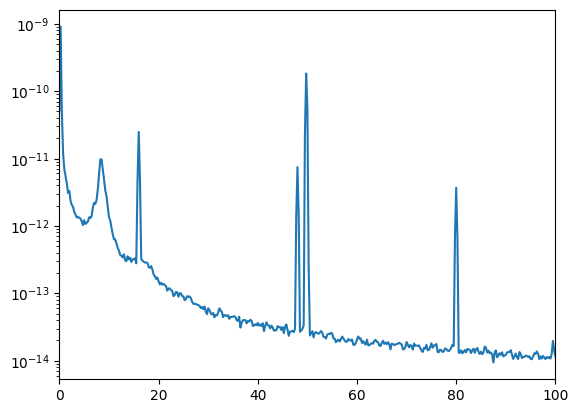

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6759 samples (6.601 s)

Effective window size : 4.000 (s)


/var/folders/84/36b4ykhj7dx3c82r40v03c580000gn/T/ipykernel_10975/458499856.py:58: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,100)


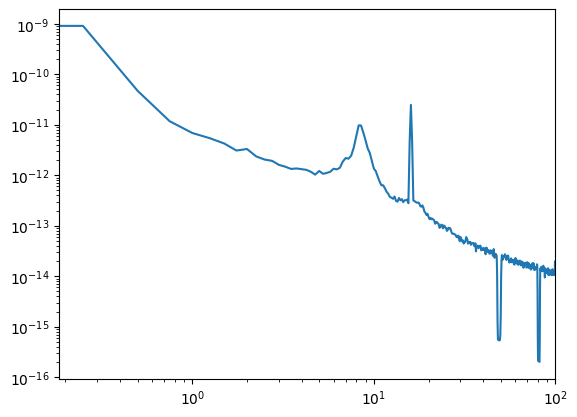

8.066191498788626e-12
6.970541211608827e-12
1.2641559890510007e-11
1.1177061023573585e-11


In [59]:
import os
import gdown
from pathlib import Path
import mne
import matplotlib.pyplot as plt
import numpy as np
import scipy
from mne.viz import plot_filter, plot_ideal_filter
import glob, os
import re
import pandas as pd
import openpyxl

raw = mne.io.read_raw_bdf(input_fname='../data/sub-070_task-med2_eeg.bdf', preload=True)
eeg_channels = raw.ch_names[:64]
#Me quedo solo con los EEG
raw_eeg=raw.copy().pick(eeg_channels)

#aplicamos pasabajos con fc=100 Hz
eeg_filtrado=raw_eeg.filter(l_freq=None, h_freq=100)

psds, freqs = mne.time_frequency.psd_array_welch(
    eeg_filtrado.get_data(), 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")

a= np.arange(49, 512, 32) 
b= np.arange(49,512,50)
freqs_notch = (np.concatenate((a,[49.7]), axis=None))
plt.plot(freqs,psds[30])
plt.semilogy()
plt.xlim(0,100)
plt.show()

#Aplico filtro nothc para sacar ruido de linea >50Hz

filtrado = mne.filter.notch_filter(
    eeg_filtrado.get_data()[30],
    Fs=1024,
    freqs=a,
    notch_widths = 2,
    method = 'fir'
)

psds_f, freqs_f = mne.time_frequency.psd_array_welch(
    filtrado, 
    sfreq=1024, 
    n_fft=4096,
    fmax=100,
    n_per_seg=4096, 
    output="power")

plt.plot(freqs_f, psds_f)
plt.loglog()
plt.xlim(0,100)
plt.show()

#ANALISIS PSD POR
bandas = [[1,4],[4, 8], [8,13],[13,30]]

for i in range(len(bandas)):
    mask = (freqs_f >= bandas[i][0]) & (freqs_f <= bandas[i][1])
    band_power = np.trapezoid(psds_f[mask],freqs_f[mask])
    print(band_power)






ANALISIS PSD

In [61]:
#ANALISIS PSD POR
raw = mne.io.read_raw_bdf(input_fname='../data/sub-070_task-med2_eeg.bdf', preload=True)
eeg_channels = raw.ch_names[:64]


regiones = {
"frontal": ["Fz", "F1", "F2", "F3", "F4"],
"central": ["Cz", "C1", "C2", "C3", "C4"],
"parietal": ["Pz", "P1", "P2", "P3", "P4"],
"occipital": ["Oz", "O1", "O2"],
}



bandas = {
"delta": [1,4],
"theta": [4,8],
"alfa": [8,13],
"beta": [13,30],
}


resultados_PSD = []
for archivo in glob.glob("../data/*.bdf"):
    numero_sujeto = int(re.search(r'sub-(\d+)', archivo).group(1))
    if numero_sujeto < 60: 
        grupo = "CTR"
    else:
        grupo = "EXP"

    print("sujeto ",numero_sujeto)
    raw = mne.io.read_raw_bdf(input_fname=archivo, preload=True)
    for region, electrodos in regiones.items():
        eeg_channels = electrodos #ME QUEDO SOLO CON LOS CANALES QUE QUIERO DE CADA REGION 
        raw_eeg=raw.copy().pick(eeg_channels) 
        #ACA APLICAR PREPROCESAMIENTO   
       #aplicamos pasabajos con fc=100 Hz
        eeg_filtrado_100=raw_eeg.filter(l_freq=None, h_freq=100)

        freqs_notch= np.arange(49, 512, 32) 

        #Aplico filtro nothc para sacar ruido de linea >50Hz
        for p in range(len(eeg_channels)):
            #region = eeg_channels[p]
            filtrado_notch = mne.filter.notch_filter(
                eeg_filtrado_100.get_data()[p],
                Fs=1024,
                freqs=freqs_notch,
                notch_widths = 2,
                method = 'fir'
            )

            psds_f, freqs_f = mne.time_frequency.psd_array_welch(
                filtrado_notch, 
                sfreq=1024, 
                n_fft=4096,
                fmax=100,
                n_per_seg=4096, 
                output="power")
            
            for banda, rango in bandas.items():
                
                mask = (freqs_f >= rango[0]) & (freqs_f <= rango[1])
                potencia = np.trapezoid(psds_f[mask],freqs_f[mask])
                
                print("el poder de la banda", band_power)

                resultados_PSD.append({
                "sujeto": numero_sujeto,
                "grupo": grupo,
                "region": region,
                "banda": banda,
                "potencia": potencia,
                })

df = pd.DataFrame(resultados_PSD)
resumen = df.groupby(["sujeto", "grupo", "region", "banda"])["potencia"].mean().reset_index()
resumen.to_csv("resumen_psd.csv", index=False)

df = pd.read_csv('resumen_psd.csv')
df["log_potencia"] = np.log10(df["potencia"])   # transformación log10

regiones = ["frontal", "central", "parietal", "occipital"]
bandas = ["delta", "theta", "alfa", "beta"]

with pd.ExcelWriter("tablas_prism_log.xlsx", engine="openpyxl") as writer:
    for region in regiones:
        for banda in bandas:
            sub = df[(df["region"] == region) & (df["banda"] == banda)]
            ctr = sub[sub["grupo"] == "CTR"]["log_potencia"].reset_index(drop=True)
            exp = sub[sub["grupo"] == "EXP"]["log_potencia"].reset_index(drop=True)
            tabla = pd.DataFrame({"CTR": ctr, "EXP": exp})
            hoja = f"{region[:4]}_{banda}"
            tabla.to_excel(writer, sheet_name=hoja, index=False)

print("Listo: tablas_prism_log.xlsx")

Extracting BDF parameters from ../data/sub-070_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 616447  =      0.000 ...   601.999 secs...
sujeto  31
Extracting BDF parameters from ../data/sub-031_task-med2_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 626687  =      0.000 ...   611.999 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 137 samples (0.134 s)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-